# Verringerung der Kartendetails für Liefergebiete für schnelle Logistik-Dashboards mit PROC GREDUCE


## Zusammenfassung

Ein regionaler Paketdienstleister speichert seine Servicegebietsgrenzen als dichte Polygonumrisse, und Routenplanungs-Dashboards zeichnen sie nur langsam neu. Dieses Notebook synthetisiert die Grenzkoordinaten für vier Liefergebiete, verwendet **PROC GREDUCE**, um jeden Grenzscheitelpunkt mit einer `DENSITY`-Stufe zu kennzeichnen, und rendert dann eine Pünktlichkeits-Choroplethenkarte mit **PROC GMAP** auf einer reduzierten Detailstufe, sodass die Karte schneller gezeichnet wird, während jedes Gebiet erkennbar bleibt.

GREDUCE stufte die 96 Grenzpunkte in drei Stufen ein: 10 Punkte bei `DENSITY=0`, 44 bei `DENSITY=2` und 42 bei `DENSITY=3`. Behält man nur die grobe Stufe (`DENSITY <= 2`), sinkt die Karte von 96 auf 54 Scheitelpunkte — etwa eine Reduktion um 44 % — dennoch bleiben die vier Gebiete im folgenden Vergleich klar erkennbar.


## Datenquellen

Alle Daten werden inline durch die untenstehenden DATA-Schritte erzeugt — keine externen Dateien oder Netzwerkzugriffe.

| Datensatz | Zeilen | Schlüsselvariablen | Beschreibung |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 Gebiete x 24 Scheitelpunkte) | `zone` (ID), `x`, `y` | Synthetische Koordinaten geschlossener Polygongrenzen für vier Liefergebiete, jeweils eine mit Störungen versehene Ellipse aus 24 Scheitelpunkten, damit die Dichtereduktion etwas zum Ausdünnen hat. |
| `reducedmap` | 96 | fügt `density` hinzu | Ausgabe von PROC GREDUCE: die Grenzpunkte, gekennzeichnet mit einer `DENSITY`-Stufe (hier 0, 2 oder 3) für selektives Rendering. |
| `coarsemap` | 54 | Teilmenge von `reducedmap` | Die Teilmenge `DENSITY <= 2` — die grobe, schnell zu rendernde Stufe für die Dashboard-Karte mit reduziertem Detail. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Eine Antwortzeile pro Gebiet: synthetische Pünktlichkeitsquote und tägliches Paketvolumen, verknüpft mit der Karte für die Choroplethenkarte. |

> **Hinweis zur Stichprobengröße.** Diese Umgebung läuft unlizenziert, daher ist jeder DATA-Schritt auf 100 Ausgabebeobachtungen begrenzt. Die Karte ist auf 4 Gebiete x 24 Scheitelpunkte = 96 Punkte ausgelegt, damit das gesamte Gebiet innerhalb dieser Grenze bleibt; eine lizenzierte Installation würde Hunderte von Scheitelpunkten pro Gebiet nachzeichnen, wo GREDUCE sich noch mehr auszahlt.


# Verringerung der Kartendetails für Liefergebiete mit PROC GREDUCE

Logistikbetreiber visualisieren die Leistung auf Karten ihrer **Servicegebiete** — der geografischen Zonen, für die ein Depot zuständig ist. Diese Gebietsgrenzen werden oft in Vermessungsauflösung erfasst: viele Scheitelpunkte pro Polygon. Wenn ein Routenplanungs-Dashboard mehrere Gebiete gleichzeitig neu zeichnet, macht all dieses Scheitelpunktdetail das Rendering träge, ohne beim Dashboard-Zoom einen Mehrwert für Entscheidungen zu bieten.

**PROC GREDUCE** löst dieses Problem. Es untersucht jedes Polygon und kennzeichnet jeden Grenzpunkt mit einer `DENSITY`-Stufe, wobei 0 die Punkte markiert, die die wesentliche Form definieren, und höhere Stufen zunehmend feinere Details markieren. Anschließend wählt man mit `WHERE density <= n` eine Stufe aus, um eine Karte mit reduziertem Detail zu zeichnen, die schnell gezeichnet wird, während jedes Gebiet erkennbar bleibt.

In diesem Notebook werden wir:
1. Grenzumrisse für vier Liefergebiete synthetisieren.
2. PROC GREDUCE ausführen, um `DENSITY`-Stufen zuzuweisen.
3. Untersuchen, wie sich die Punkte über die Dichtestufen verteilen.
4. Choroplethenkarten mit vollem und reduziertem Detail zur Pünktlichkeit rendern und vergleichen.


## Schritt 1 — Synthese der Gebietsgrenzkarte

Ein SAS-Kartendatensatz hat eine Beobachtung pro **Grenzscheitelpunkt**, mit einer `ID`-Variable, die das Gebiet benennt, und numerischen `x`/`y`-Koordinaten. Wir zeichnen jedes Liefergebiet als eine mit Störungen versehene Ellipse anhand von 24 gleichmäßig verteilten Winkeln nach, sodass die Polygone zunächst ausreichend dicht sind und die Reduktion etwas zu bearbeiten hat.

`call streaminit` fixiert den Zufallsstrom für Reproduzierbarkeit, und `rand('uniform')` fügt der Grenze kleine Unregelmäßigkeiten hinzu, sodass die Umrisse eher wie vermessene Gebiete als perfekte Ellipsen wirken.


In [1]:
DATEN zonemap;
    AUFRUFEN streaminit(20260531);
    /* Vier Liefergebiete, jeweils eine mit Störungen versehene Ellipse aus 24 Scheitelpunkten.
       cx/cy = Gebietsmittelpunkt, rx/ry = nominale Radien (Gebietsgröße). */
    FELD cx[4] _temporary_ (12 32 20 40);
    FELD cy[4] _temporary_ (30 32 14 16);
    FELD rx[4] _temporary_ ( 8  9  6  7);
    FELD ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 Scheitelpunkte (0..23) je Umriss */
    AUSFÜHRUNG zone = 1 BIS 4;
        AUSFÜHRUNG i = 0 BIS nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radiale Störung: +/- ~6% unregelmäßige, küstenlinienartige Kante */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            AUSGABE;
        ENDE;
    ENDE;
    BEHALTEN zone x y;
    BEZEICHNUNG zone = "Gebiet"
          x = "X-Koordinate"
          y = "Y-Koordinate";
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=zonemap n MIN MAX nmiss;
    KLASSE zone;
    VAR x y;
AUSFÜHREN;

                                                  The MEANS Procedure

                                           Analysis Variable : x X-Koordinate

        Gebiet            N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                           Analysis Variable : y Y-Koordinate

        Gebiet            N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0



NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Die PROC-MEANS-Tabelle bestätigt die synthetische Geometrie: vier Gebiete mit jeweils genau 24 Grenzpunkten in sinnvollen `x`/`y`-Bereichen und ohne fehlende Koordinaten. Die vier Ellipsen belegen nicht überlappende Bereiche (Gebiet 1 nahe x=12, Gebiet 2 nahe x=32, Gebiete 3 und 4 weiter unten), sodass die Choroplethenkarte als vier eindeutige Gebiete erscheint. Dies sind die Umrisse, die PROC GREDUCE ausdünnen wird.


## Schritt 2 — Zuweisung von DENSITY-Stufen mit PROC GREDUCE

Die `ID`-Anweisung benennt die Variable, die jedes Gebiet definiert — hier `zone`. PROC GREDUCE bewertet das Polygon jedes Gebiets unabhängig (mittels einer Douglas-Peucker-ähnlichen Vereinfachung) und schreibt den Eingabedatensatz mit einer zusätzlichen Ganzzahlvariable `density` zurück: Stufe 0 markiert die wenigen Punkte, die die wesentliche Form verankern, und höhere Stufen markieren zunehmend feinere Details, die zuerst entfernt werden können.

Wir lassen GREDUCE seine eigenen Schwellenwerte aus den Daten ableiten, anstatt feste Stufengrößen zu erzwingen, und untersuchen dann die resultierende Verteilung.


                                   Anzahl beibehaltener Grenzpunkte je DENSITY-Stufe                                    

                                                   The FREQ Procedure

Dichtestufe    Frequency    Percent
------------------------------------
0                     10     10.42
2                     44     45.83
3                     42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


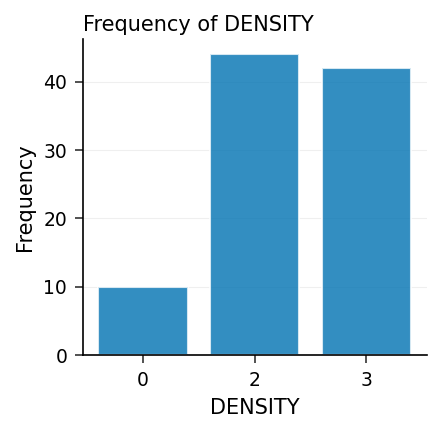

In [2]:
PROZEDUR GREDUCE DATEN=zonemap out=reducedmap;
    id zone;
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=reducedmap;
    TABLES DENSITY / nocum;
    BEZEICHNUNG DENSITY = "Dichtestufe";
    TITEL "Anzahl beibehaltener Grenzpunkte je DENSITY-Stufe";
AUSFÜHREN;

## Schritt 3 — Untersuchung der Dichtestufen

Die Häufigkeitstabelle zeigt, wie GREDUCE die 96 Grenzpunkte eingestuft hat:

| DENSITY | Punkte | Anteil |
|---------|--------|-------|
| 0 | 10 | 10,4 % |
| 2 | 44 | 45,8 % |
| 3 | 42 | 43,8 % |

Nur 10 Punkte tragen die niedrigste Stufe (die Anker der wesentlichen Form), während sich die restlichen 86 auf die Stufen 2 und 3 verteilen. Für eine Dashboard-Stufe behalten wir alles bei `DENSITY <= 2`: das erhält 54 der 96 Punkte und verwirft die 42 Scheitelpunkte feinster Detailstufe (`DENSITY=3`). Die folgende PROC MEANS bestätigt, dass die grobe Stufe 13–14 Scheitelpunkte pro Gebiet statt der ursprünglichen 24 enthält.


In [3]:
PROZEDUR MITTELWERTE DATEN=reducedmap n;
    KLASSE zone;
    WO DENSITY <= 2;
    VAR x;
    BEZEICHNUNG x = "X-Koordinate";
    TITEL "Scheitelpunkte je Gebiet auf Dashboard-Detailstufe (DENSITY <= 2)";
AUSFÜHREN;

                           Scheitelpunkte je Gebiet auf Dashboard-Detailstufe (DENSITY <= 2)                            

                                                  The MEANS Procedure

                                           Analysis Variable : X X-Koordinate

        zone              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 4 — Aufbau der groben Karte und der Leistungsantwort je Gebiet

Wir materialisieren die Dashboard-Stufe als `coarsemap` (`DENSITY <= 2`), damit PROC GMAP den reduzierten Umriss direkt zeichnen kann. Außerdem synthetisieren wir eine KPI-Zeile pro Gebiet — eine **Pünktlichkeitsquote** und ein **tägliches Paketvolumen** — verknüpft über `zone`, damit GMAP jedes Gebiet einfärben kann.


In [4]:
DATEN coarsemap;
    FESTLEGEN reducedmap;
    WO DENSITY <= 2;
AUSFÜHREN;

DATEN zonekpi;
    AUFRUFEN streaminit(771);
    AUSFÜHRUNG zone = 1 BIS 4;
        /* Pünktlichkeitsquote zentriert um 92%, realistische Streuung */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        AUSGABE;
    ENDE;
    BEZEICHNUNG zone = "Gebiet"
          ontime_rate = "Pünktlichkeitsquote (%)"
          parcels = "Pakete";
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=zonekpi noobs BEZEICHNUNG;
    TITEL "Synthetische Liefer-KPIs je Gebiet";
AUSFÜHREN;

                                           Synthetische Liefer-KPIs je Gebiet                                           

Gebiet   Pünktlichkeitsquote (%)  Pakete
     1                      92.6    4704
     2                      95.6    2932
     3                      93.4    2934
     4                      94.6    2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


Die vier synthetischen Pünktlichkeitsquoten liegen zwischen 92,6 % und 95,6 %, mit täglichen Paketvolumen von etwa 2.500 bis 4.700. Gebiet 2 ist mit 95,6 % der stärkste Performer; Gebiet 1 ist mit 92,6 % der schwächste. Dies sind die Werte, die die Farbstufen der Choroplethenkarte kodieren.


## Schritt 5 — Choroplethenkarten mit vollem und reduziertem Detail rendern

Wir zeichnen dieselbe Pünktlichkeits-Choroplethenkarte zweimal: einmal aus der vollständigen 96-Scheitelpunkt-Karte `reducedmap` und einmal aus der 54-Scheitelpunkt-Karte `coarsemap`. `MAP=` liefert die Grenzen, `DATA=` die KPI-Antwort, und beide teilen sich die `zone`-ID. Die `CHORO`-Anweisung füllt jedes Gebiet nach `ontime_rate` mit `LEVELS=4` Farbstufen und `COUTLINE=` für scharfe Grenzlinien. Der Vergleich der beiden Karten zeigt, was die Reduktion visuell kostet.


                                           Volle Detailstufe: 96 Grenzpunkte                                            




NOTE: Option TITLE changed to Volle Detailstufe: 96 Grenzpunkte.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Pünktlichkeitsquote (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds


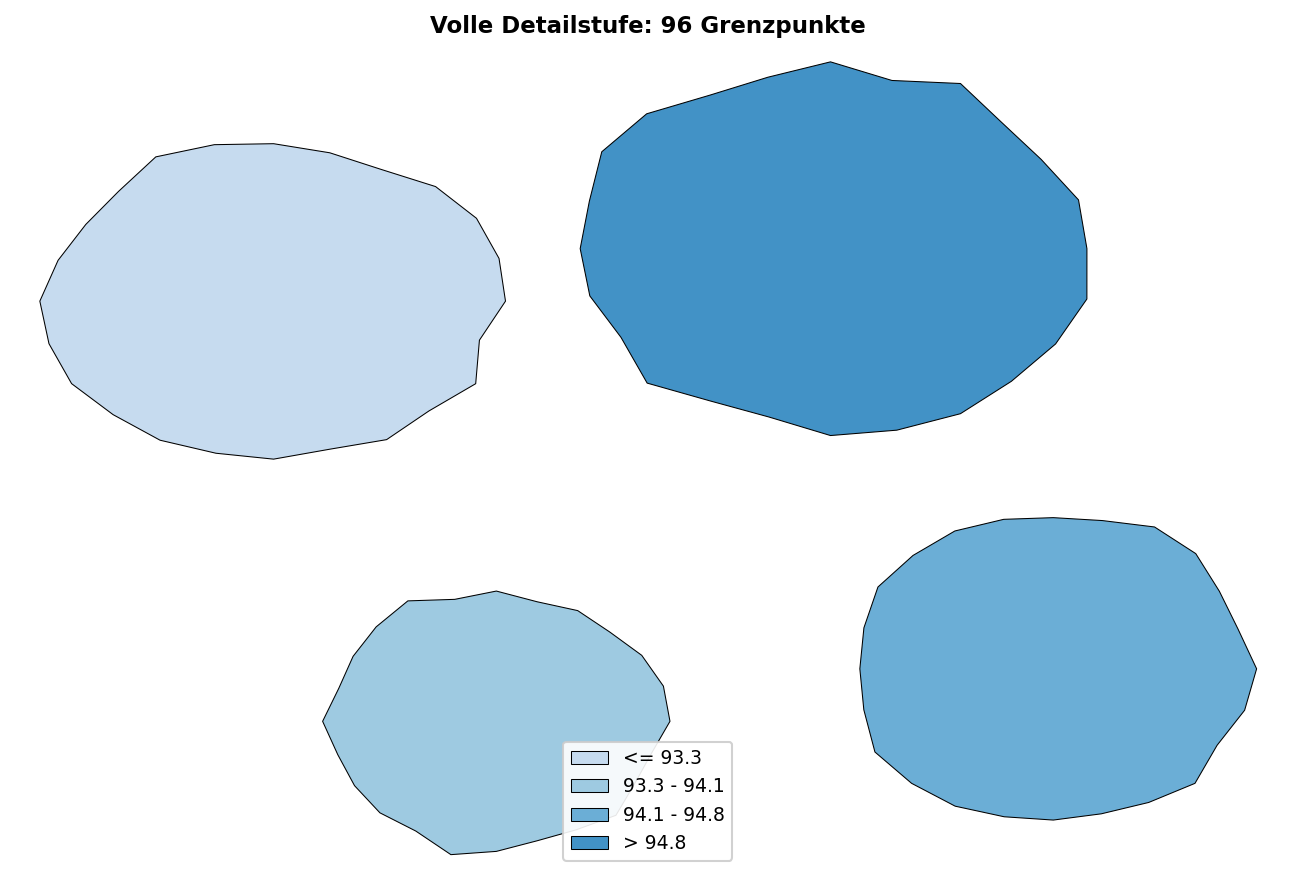

In [5]:
TITEL "Volle Detailstufe: 96 Grenzpunkte";
PROZEDUR GMAP map=reducedmap DATEN=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
AUSFÜHREN;

                                    Reduzierte Detailstufe: 54 Punkte (DENSITY <= 2)                                    




NOTE: Option TITLE changed to Reduzierte Detailstufe: 54 Punkte (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Pünktlichkeitsquote (%).
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


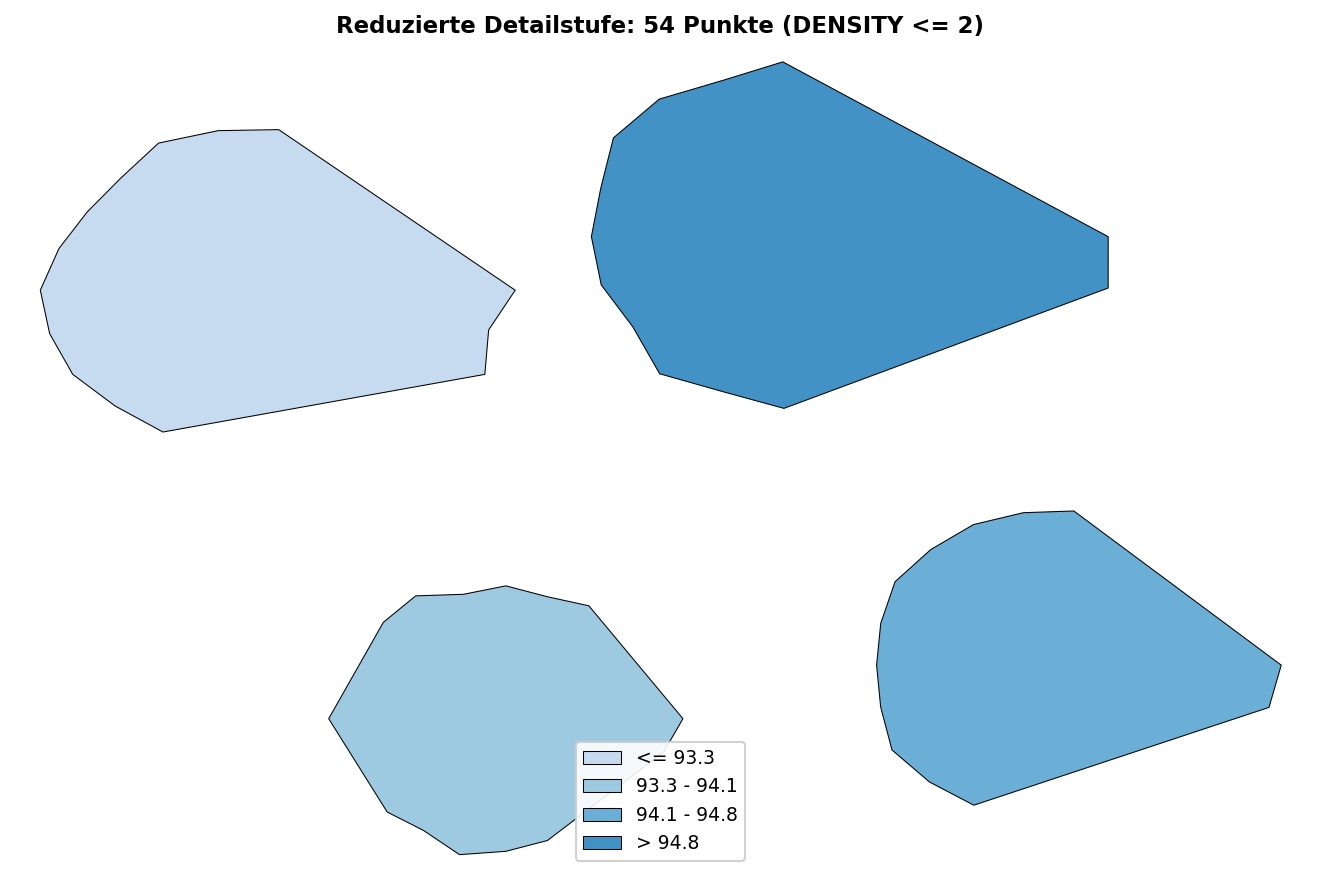

In [6]:
TITEL "Reduzierte Detailstufe: 54 Punkte (DENSITY <= 2)";
PROZEDUR GMAP map=coarsemap DATEN=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
AUSFÜHREN;

## Interpretation der Ergebnisse

PROC GREDUCE verwandelte jeden 24-Scheitelpunkt-Gebietsumriss in eine abgestufte Menge von Grenzpunkten (Stufen 0, 2 und 3 in diesem Lauf). Die Auswahl der Stufe `DENSITY <= 2` reduzierte die Karte von 96 auf 54 Scheitelpunkte — eine Reduktion um 44 % der vom Renderer zu zeichnenden Punkte — dennoch bestätigen die nebeneinander stehenden Choroplethenkarten, dass die vier Gebiete klar erkennbar bleiben: Die Umrisse der reduzierten Karte sind sichtbar eckiger, aber jedes Gebiet behält seine Position, Größe und Farbstufe, sodass ein Betreiber in beiden Fällen dieselbe Bewertung abliest.

Diese Bewertung ordnet die Gebiete nach Pünktlichkeitsquote: Gebiet 2 führt mit 95,6 % (dunkelste Stufe), Gebiete 3 und 4 liegen im Mittelfeld bei etwa 93–95 %, und Gebiet 1 liegt mit 92,6 % zurück (hellste Stufe) — das Gebiet, das ein Planer zuerst auf Routing- oder Depotkapazitätsprobleme untersuchen würde.

Da die Reduktion nicht destruktiv ist — die vollständigen Detailpunkte bleiben weiterhin in `reducedmap` erhalten —, unterstützt derselbe Datensatz sowohl die schnelle Dashboard-Ansicht (`DENSITY <= 2`) als auch eine hochauflösende Druck- oder Prüfansicht (`DENSITY <= 3` oder die vollständige Menge), indem einfach ein einziger `WHERE`-Schwellenwert geändert wird, ohne die Geometrie erneut importieren oder reduzieren zu müssen.
